# Handling mising values-neumerical data

In [1]:
# 1. using pandas 2. using sklearn


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from  sklearn.compose import ColumnTransformer

In [4]:
df= pd .read_csv(r"C:\Users\sus\Downloads\titanic_toy.csv")


In [5]:
df

,Age,Fare,Family,Survived
0,22.0,7.2500,1,0
1,38.0,71.2833,1,1
2,26.0,7.9250,0,1
3,35.0,53.1000,1,1
4,35.0,8.0500,0,0
...,...,...,...,...
886,27.0,13.0000,0,0
887,19.0,30.0000,0,1
888,NaN,23.4500,3,0
889,26.0,NaN,0,1


In [6]:
df.isnull().sum()


Age         177
Fare         45
Family        0
Survived      0
dtype: int64

In [7]:
df.isnull().mean()*100

Age         19.865320
Fare         5.050505
Family       0.000000
Survived     0.000000
dtype: float64

In [8]:
x=df.drop(columns=["Survived"])
y=df["Survived"]

In [9]:
x_train,x_test,y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [10]:
x_train.shape,x_test.shape


((712, 3), (179, 3))

In [11]:
mean_age=x_train["Age"].mean()
median_age=x_train["Age"].median()

mean_fare=x_train["Fare"].mean
median_fare=x_train["Fare"].median



In [12]:
x_train["Age_median"]=x_train["Age"].fillna(median_age)
x_train["Age_mean"]= x_train["Age"].fillna(mean_age)
x_train["Fare_mean"]= x_train["Fare"].fillna(mean_fare)
x_train["Fare_median"]= x_train["Fare"].fillna(median_fare)


x_train["Fare_median"] = pd.to_numeric(x_train["Fare_median"], errors="coerce")
x_train["Fare_mean"] = pd.to_numeric(x_train["Fare_mean"], errors="coerce")









In [13]:
print(x_train["Fare_mean"].dtype)
print(x_train["Fare_median"].dtype)



float64
float64


In [14]:
x_train.sample(3)

,Age,Fare,Family,Age_median,Age_mean,Fare_mean,Fare_median
332,38.0,153.4625,1,38.00,38.000000,153.4625,153.4625
235,NaN,7.5500,0,28.75,29.785904,7.5500,7.5500
864,24.0,13.0000,0,24.00,24.000000,13.0000,13.0000


In [15]:
print("original age variable variance",x_train["Age"].var())
print("Age variance after median imputation",x_train["Age_median"].var())
print("age variance after mean imputation",x_train["Age_mean"].var())

print("original fare variable variance", x_train["Fare"].var())
print("fare variance after median imputation",x_train["Fare_median"].var())
print("fare variance after mean imputation",x_train["Fare_mean"].var())

original age variable variance 204.3495133904614
Age variance after median imputation 161.9895663346054
age variance after mean imputation 161.81262452718673
original fare variable variance 2448.197913706318
fare variance after median imputation 2448.197913706318
fare variance after mean imputation 2448.197913706318


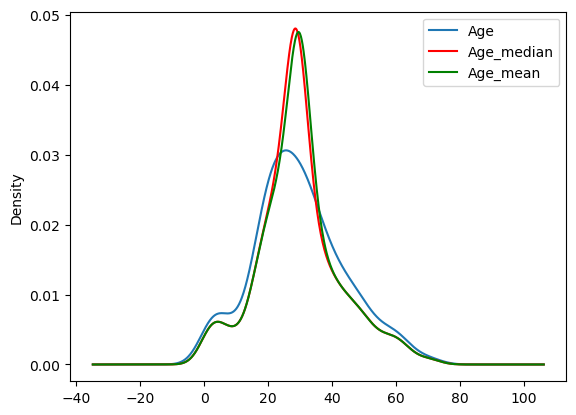

In [16]:
fig=plt.figure()
ax=fig.add_subplot(111)
#orignal variable distribution
x_train["Age"].plot(kind="kde",ax=ax)
#variable imputed with the median 
x_train["Age_median"].plot(kind="kde", ax=ax, color="red")
# variable imputed with mean
x_train["Age_mean"].plot(kind="kde", ax=ax , color="green")
#adding legends
lines, labels= ax.get_legend_handles_labels()
ax.legend(lines, labels, loc= "best")

In [17]:
# on examining the above curve we can say that there is a drastic change in the distribution of age if imputed with mean and median

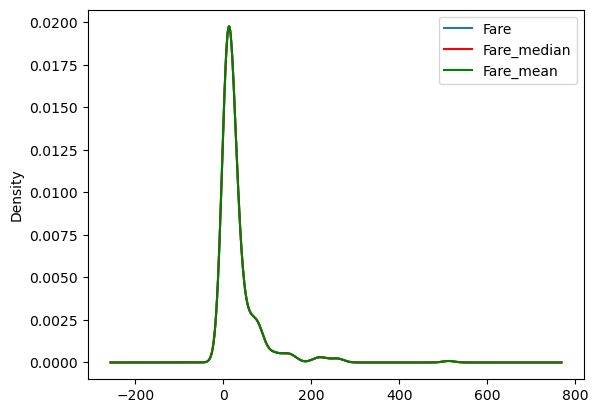

In [18]:
fig=plt.figure()
ax=fig.add_subplot(111)
#orignal variable distribution
x_train["Fare"].plot(kind="kde",ax=ax)
#variable imputed with the median 
x_train["Fare_median"].plot(kind="kde", ax=ax, color="red")
# variable imputed with mean
x_train["Fare_mean"].plot(kind="kde", ax=ax , color="green")
#adding legends
lines, labels= ax.get_legend_handles_labels()
ax.legend(lines, labels, loc= "best")

In [19]:
x_train.cov()

,Age,Fare,Family,Age_median,Age_mean,Fare_mean,Fare_median
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,70.719262,70.719262
Fare,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-5.112563,-5.146106,17.258917,17.258917
Age_median,204.349513,57.957599,-5.112563,161.989566,161.812625,57.957599,57.957599
Age_mean,204.349513,55.603719,-5.146106,161.812625,161.812625,55.603719,55.603719
Fare_mean,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914
Fare_median,70.719262,2448.197914,17.258917,57.957599,55.603719,2448.197914,2448.197914


In [20]:
x_train.corr()

,Age,Fare,Family,Age_median,Age_mean,Fare_mean,Fare_median
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.092644,0.092644
Fare,0.092644,1.000000,0.208268,0.091757,0.088069,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.242883,-0.244610,0.208268,0.208268
Age_median,1.000000,0.091757,-0.242883,1.000000,0.999454,0.091757,0.091757
Age_mean,1.000000,0.088069,-0.244610,0.999454,1.000000,0.088069,0.088069
Fare_mean,0.092644,1.000000,0.208268,0.091757,0.088069,1.000000,1.000000
Fare_median,0.092644,1.000000,0.208268,0.091757,0.088069,1.000000,1.000000


<Axes: >

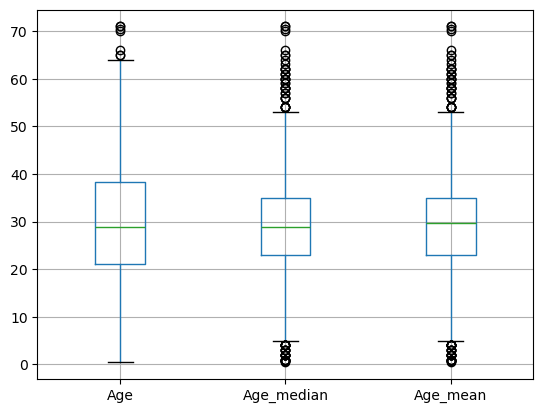

In [21]:
x_train[["Age","Age_median",'Age_mean']].boxplot()

<Axes: >

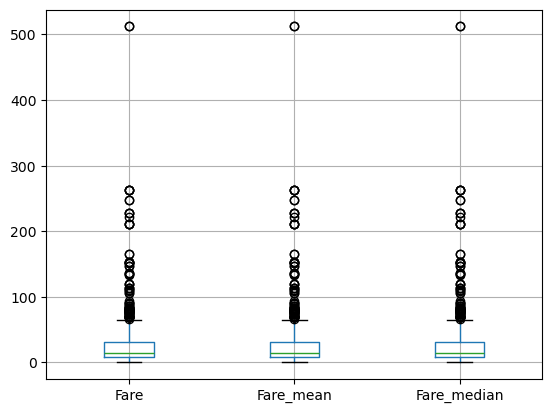

In [22]:
x_train[["Fare", "Fare_mean","Fare_median"]].boxplot()

# using sklearn

In [23]:
x_train,x_test,y_train ,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [24]:
imputer1=SimpleImputer(strategy="median")
imputer2=SimpleImputer(strategy="mean")



In [25]:
trf=ColumnTransformer([
("imputer1",imputer1,["Age"]),
("imputer2",imputer2,["Fare"])],
                      remainder="passthrough"
)

In [26]:
trf.fit(x_train)

C:\Users\sus\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1', SimpleImputer(strategy='median'),
                                 ['Age']),
                                ('imputer2', SimpleImputer(), ['Fare'])])

In [27]:
trf.named_transformers_["imputer1"].statistics_

array([28.])

In [28]:
trf.named_transformers_["imputer2"].statistics_

array([32.51778772])

In [29]:
x_train=trf.transform(x_train)
x_test=trf.transform(x_test)

In [30]:
x_train

array([[ 45.5       ,  28.5       ,   0.        ],
       [ 23.        ,  13.        ,   0.        ],
       [ 32.        ,   7.925     ,   0.        ],
       ...,
       [ 41.        ,  32.51778772,   2.        ],
       [ 14.        , 120.        ,   3.        ],
       [ 21.        ,  77.2875    ,   1.        ]])

# Arbitary value imputation
### replace n/a with "missing " in categorical data
### and replace n/a with some number in numerical data

### used whrn data in not  mising at random

In [31]:
x_train,x_test,y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [32]:
x_train["Age_99"]=x_train["Age"].fillna(99)
x_train["Age_minus1"]= x_train["Age"].fillna(-1)
x_train["Fare_999"]= x_train["Fare"].fillna(999)
x_train["Fare_minus1"]= x_train["Fare"].fillna(-1)

In [33]:
print("original age variable variance",x_train["Age"].var())
print("Age variance after median imputation",x_train["Age_99"].var())
print("age variance after mean imputation",x_train["Age_minus1"].var())

print("original fare variable variance", x_train["Fare"].var())
print("fare variance after median imputation",x_train["Fare_999"].var())
print("fare variance after mean imputation",x_train["Fare_minus1"].var())

original age variable variance 204.3495133904614
Age variance after median imputation 951.7275570187172
age variance after mean imputation 318.0896202624484
original fare variable variance 2448.197913706318
fare variance after median imputation 47219.20265217623
fare variance after mean imputation 2378.5676784883503


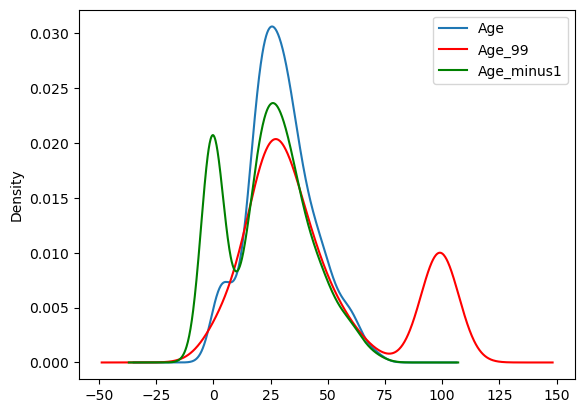

In [34]:
fig = plt.figure()
ax=fig.add_subplot(111)
#original variance distribution
x_train["Age"].plot(kind="kde",ax=ax)

x_train["Age_99"].plot(kind="kde",ax=ax,color="red")

x_train["Age_minus1"].plot(kind="kde",ax=ax,color="green")

lines, labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc="best")

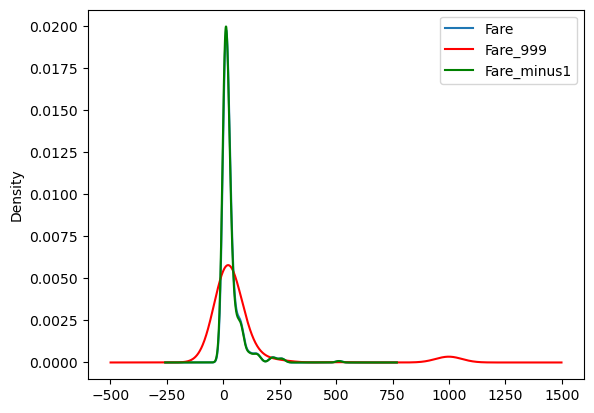

In [35]:
fig = plt.figure()
ax=fig.add_subplot(111)
#original variance distribution
x_train["Fare"].plot(kind="kde",ax=ax)

x_train["Fare_999"].plot(kind="kde",ax=ax,color="red")

x_train["Fare_minus1"].plot(kind="kde",ax=ax,color="green")

lines, labels=ax.get_legend_handles_labels()
ax.legend(lines,labels,loc="best")

In [36]:
x_train.cov()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,204.349513,70.719262,-6.498901,204.349513,204.349513,162.793430,63.321188
Fare,70.719262,2448.197914,17.258917,-101.671097,125.558364,2448.197914,2448.197914
Family,-6.498901,17.258917,2.735252,-7.387287,-4.149246,11.528625,16.553989
Age_99,204.349513,-101.671097,-7.387287,951.727557,-189.535540,-159.931663,-94.317400
Age_minus1,204.349513,125.558364,-4.149246,-189.535540,318.089620,257.379887,114.394141
Fare_999,162.793430,2448.197914,11.528625,-159.931663,257.379887,47219.202652,762.474982
Fare_minus1,63.321188,2448.197914,16.553989,-94.317400,114.394141,762.474982,2378.567678


In [37]:
x_train.corr()

,Age,Fare,Family,Age_99,Age_minus1,Fare_999,Fare_minus1
Age,1.000000,0.092644,-0.299113,1.000000,1.000000,0.051179,0.084585
Fare,0.092644,1.000000,0.208268,-0.066273,0.142022,1.000000,1.000000
Family,-0.299113,0.208268,1.000000,-0.144787,-0.140668,0.032079,0.205233
Age_99,1.000000,-0.066273,-0.144787,1.000000,-0.344476,-0.023857,-0.062687
Age_minus1,1.000000,0.142022,-0.140668,-0.344476,1.000000,0.066411,0.131514
Fare_999,0.051179,1.000000,0.032079,-0.023857,0.066411,1.000000,0.071946
Fare_minus1,0.084585,1.000000,0.205233,-0.062687,0.131514,0.071946,1.000000


#  using sklearn

In [38]:
x_train,x_test,y_train, y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [44]:
imputer1=SimpleImputer(strategy="constant", fill_value=99)
imputer2=SimpleImputer(strategy="constant",fill_value=99)

In [45]:
trf=ColumnTransformer([
("imputer1",imputer1,["Age"]),
("imputer2",imputer2,["Fare"])],
                      remainder="passthrough"
)

In [46]:
trf.fit(x_train)

C:\Users\sus\anaconda3\Lib\site-packages\sklearn\compose\_column_transformer.py:1623: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


ColumnTransformer(remainder='passthrough',
                  transformers=[('imputer1',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['Age']),
                                ('imputer2',
                                 SimpleImputer(fill_value=99,
                                               strategy='constant'),
                                 ['Fare'])])

In [51]:
trf.named_transformers_["imputer1"].statistics_


array([99.])

In [52]:
trf.named_transformers_["imputer2"].statistics_


array([99.])

In [53]:
x_train=trf.transform(x_train)
x_test=trf.transform(x_test)

In [54]:
x_train

array([[ 40.    ,  27.7208,   0.    ],
       [  4.    ,  16.7   ,   2.    ],
       [ 47.    ,   9.    ,   0.    ],
       ...,
       [ 71.    ,  49.5042,   0.    ],
       [ 99.    , 221.7792,   0.    ],
       [ 99.    ,  25.925 ,   0.    ]])

# End of distribution imputation